## 1. 모든 음식점을 그래프로 그리기

- 노드: 음식점 40개
- 간선: 음식점 사이 이동 시간 정보 60개 (10m/s 이동 기준, 초 단위)

![그래프](./graph.png)

In [33]:
import math

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

KOREAN_FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
KOREAN_FONT = fm.FontProperties(fname=KOREAN_FONT_PATH)


def set_korean_font():
    fm.fontManager.addfont(KOREAN_FONT_PATH)
    font_name = KOREAN_FONT.get_name()
    plt.rcParams["font.family"] = [font_name]
    plt.rcParams["font.sans-serif"] = [font_name]
    plt.rcParams["axes.unicode_minus"] = False


set_korean_font()
from matplotlib.animation import FFMpegWriter


In [34]:
# 음식점 데이터: 별도 파일을 읽지 않고 코드 안에 직접 저장
restaurants = [{'name': '금돼지식당', 'lat': 37.55708904, 'lon': 127.01166748},
 {'name': '몽탄', 'lat': 37.53599002, 'lon': 126.97223455},
 {'name': '보니스피자펍', 'lat': 37.54117453, 'lon': 126.98694743},
 {'name': '카페 할아버지공장', 'lat': 37.54117101, 'lon': 127.05495562},
 {'name': '카린지_린가네 스낵바', 'lat': 37.54575174, 'lon': 127.04597403},
 {'name': '정돈 대학로본점', 'lat': 37.58180485, 'lon': 127.00109772},
 {'name': '제스티살룬 성수', 'lat': 37.54756785, 'lon': 127.04244231},
 {'name': '스태픽스', 'lat': 37.57749668, 'lon': 126.96812518},
 {'name': '진저베어', 'lat': 37.50909072, 'lon': 127.10538378},
 {'name': '온천집', 'lat': 37.57402303, 'lon': 126.98980243},
 {'name': '어글리베이커리', 'lat': 37.55502766, 'lon': 126.90606107},
 {'name': '까폼', 'lat': 37.52487245, 'lon': 127.0379862},
 {'name': '미미면가 가로수길점', 'lat': 37.52006405, 'lon': 127.02109781},
 {'name': '우와 홍대본점', 'lat': 37.55168245, 'lon': 126.92216364},
 {'name': '더숲 초소책방', 'lat': 37.58595188, 'lon': 126.96427069},
 {'name': '효뜨', 'lat': 37.52877016, 'lon': 126.97021428},
 {'name': '구복만두', 'lat': 37.54540346, 'lon': 126.97298325},
 {'name': '무탄 압구정 본점', 'lat': 37.52729385, 'lon': 127.03030931},
 {'name': '더 스팟 패뷸러스', 'lat': 37.56212833, 'lon': 126.98222937},
 {'name': '위트앤미트 강남점', 'lat': 37.50367605, 'lon': 127.02748174},
 {'name': '황생가칼국수', 'lat': 37.58007629, 'lon': 126.98066677},
 {'name': '단디 잠실본점', 'lat': 37.5092153, 'lon': 127.11032769},
 {'name': '진미식당', 'lat': 37.5506074, 'lon': 126.95579529},
 {'name': '우래옥', 'lat': 37.56821144, 'lon': 126.99870852},
 {'name': '진미평양냉면', 'lat': 37.51613968, 'lon': 127.03603714},
 {'name': '필동면옥', 'lat': 37.56038913, 'lon': 126.99691536},
 {'name': '애플하우스', 'lat': 37.48628158, 'lon': 126.98066071},
 {'name': '옥동식', 'lat': 37.55266334, 'lon': 126.91452552},
 {'name': '농민백암순대 본점', 'lat': 37.5037302, 'lon': 127.05297174},
 {'name': '바다회사랑 연남점', 'lat': 37.56041106, 'lon': 126.92105457},
 {'name': '툭툭누들타이', 'lat': 37.56519378, 'lon': 126.92404085},
 {'name': '송화산시도삭면', 'lat': 37.537897, 'lon': 127.06650927},
 {'name': '화목순대국', 'lat': 37.51934227, 'lon': 126.93150008},
 {'name': '이속우화', 'lat': 37.53494594, 'lon': 127.01023861},
 {'name': '키에리', 'lat': 37.5333687, 'lon': 126.99318076},
 {'name': '옥경이네건생선', 'lat': 37.56609875, 'lon': 127.01953503},
 {'name': '정육면체 신촌점', 'lat': 37.55683521, 'lon': 126.9345893},
 {'name': '영일분식', 'lat': 37.51631233, 'lon': 126.88967727},
 {'name': '청와옥 본점', 'lat': 37.51531399, 'lon': 127.11752674},
 {'name': '송계옥 성수점', 'lat': 37.54477483, 'lon': 127.05933774}]

edges = [('카린지_린가네 스낵바', '제스티살룬 성수', 37.112),
 ('진저베어', '단디 잠실본점', 43.63),
 ('카페 할아버지공장', '송계옥 성수점', 55.664),
 ('바다회사랑 연남점', '툭툭누들타이', 59.339),
 ('우와 홍대본점', '옥동식', 68.212),
 ('까폼', '무탄 압구정 본점', 72.857),
 ('어글리베이커리', '옥동식', 79.113),
 ('몽탄', '효뜨', 82.234),
 ('우래옥', '필동면옥', 88.404),
 ('단디 잠실본점', '청와옥 본점', 92.902),
 ('카페 할아버지공장', '카린지_린가네 스낵바', 94.154),
 ('우와 홍대본점', '바다회사랑 연남점', 97.549),
 ('까폼', '진미평양냉면', 98.614),
 ('송화산시도삭면', '송계옥 성수점', 99.232),
 ('스태픽스', '더숲 초소책방', 99.965),
 ('온천집', '우래옥', 101.671),
 ('보니스피자펍', '키에리', 102.735),
 ('몽탄', '구복만두', 104.881),
 ('온천집', '황생가칼국수', 104.939),
 ('스태픽스', '황생가칼국수', 114.183),
 ('미미면가 가로수길점', '무탄 압구정 본점', 114.289),
 ('금돼지식당', '옥경이네건생선', 121.844),
 ('우와 홍대본점', '정육면체 신촌점', 123.616),
 ('더 스팟 패뷸러스', '필동면옥', 130.886),
 ('보니스피자펍', '구복만두', 131.791),
 ('정돈 대학로본점', '온천집', 131.892),
 ('금돼지식당', '필동면옥', 135.115),
 ('이속우화', '키에리', 151.429),
 ('위트앤미트 강남점', '진미평양냉면', 157.803),
 ('구복만두', '진미식당', 162.202),
 ('미미면가 가로수길점', '이속우화', 191.19),
 ('진미식당', '정육면체 신촌점', 199.353),
 ('구복만두', '더 스팟 패뷸러스', 203.05),
 ('진미평양냉면', '농민백암순대 본점', 203.353),
 ('카페 할아버지공장', '까폼', 235.021),
 ('효뜨', '화목순대국', 357.147),
 ('화목순대국', '영일분식', 370.396),
 ('위트앤미트 강남점', '애플하우스', 456.11),
 ('진저베어', '농민백암순대 본점', 466.15),
 ('옥동식', '바다회사랑 연남점', 103.607),
 ('카페 할아버지공장', '송화산시도삭면', 108.179),
 ('카린지_린가네 스낵바', '송계옥 성수점', 118.319),
 ('바다회사랑 연남점', '정육면체 신촌점', 125.757),
 ('진저베어', '청와옥 본점', 127.514),
 ('카페 할아버지공장', '제스티살룬 성수', 131.265),
 ('툭툭누들타이', '정육면체 신촌점', 131.467),
 ('무탄 압구정 본점', '진미평양냉면', 133.921),
 ('미미면가 가로수길점', '진미평양냉면', 138.796),
 ('몽탄', '보니스피자펍', 141.958),
 ('어글리베이커리', '바다회사랑 연남점', 145.09),
 ('어글리베이커리', '우와 홍대본점', 146.743),
 ('온천집', '더 스팟 패뷸러스', 148.151),
 ('우와 홍대본점', '툭툭누들타이', 151.148),
 ('제스티살룬 성수', '송계옥 성수점', 152.157),
 ('정돈 대학로본점', '우래옥', 152.612),
 ('까폼', '미미면가 가로수길점', 158.246),
 ('더숲 초소책방', '황생가칼국수', 158.566),
 ('더 스팟 패뷸러스', '우래옥', 160.225),
 ('옥동식', '툭툭누들타이', 162.63),
 ('온천집', '필동면옥', 164.053)]


In [35]:
G = nx.Graph()

for restaurant in restaurants:
    G.add_node(
        restaurant["name"],
        lat=restaurant["lat"],
        lon=restaurant["lon"],
    )

for source, target, weight in edges:
    G.add_edge(source, target, weight=weight)

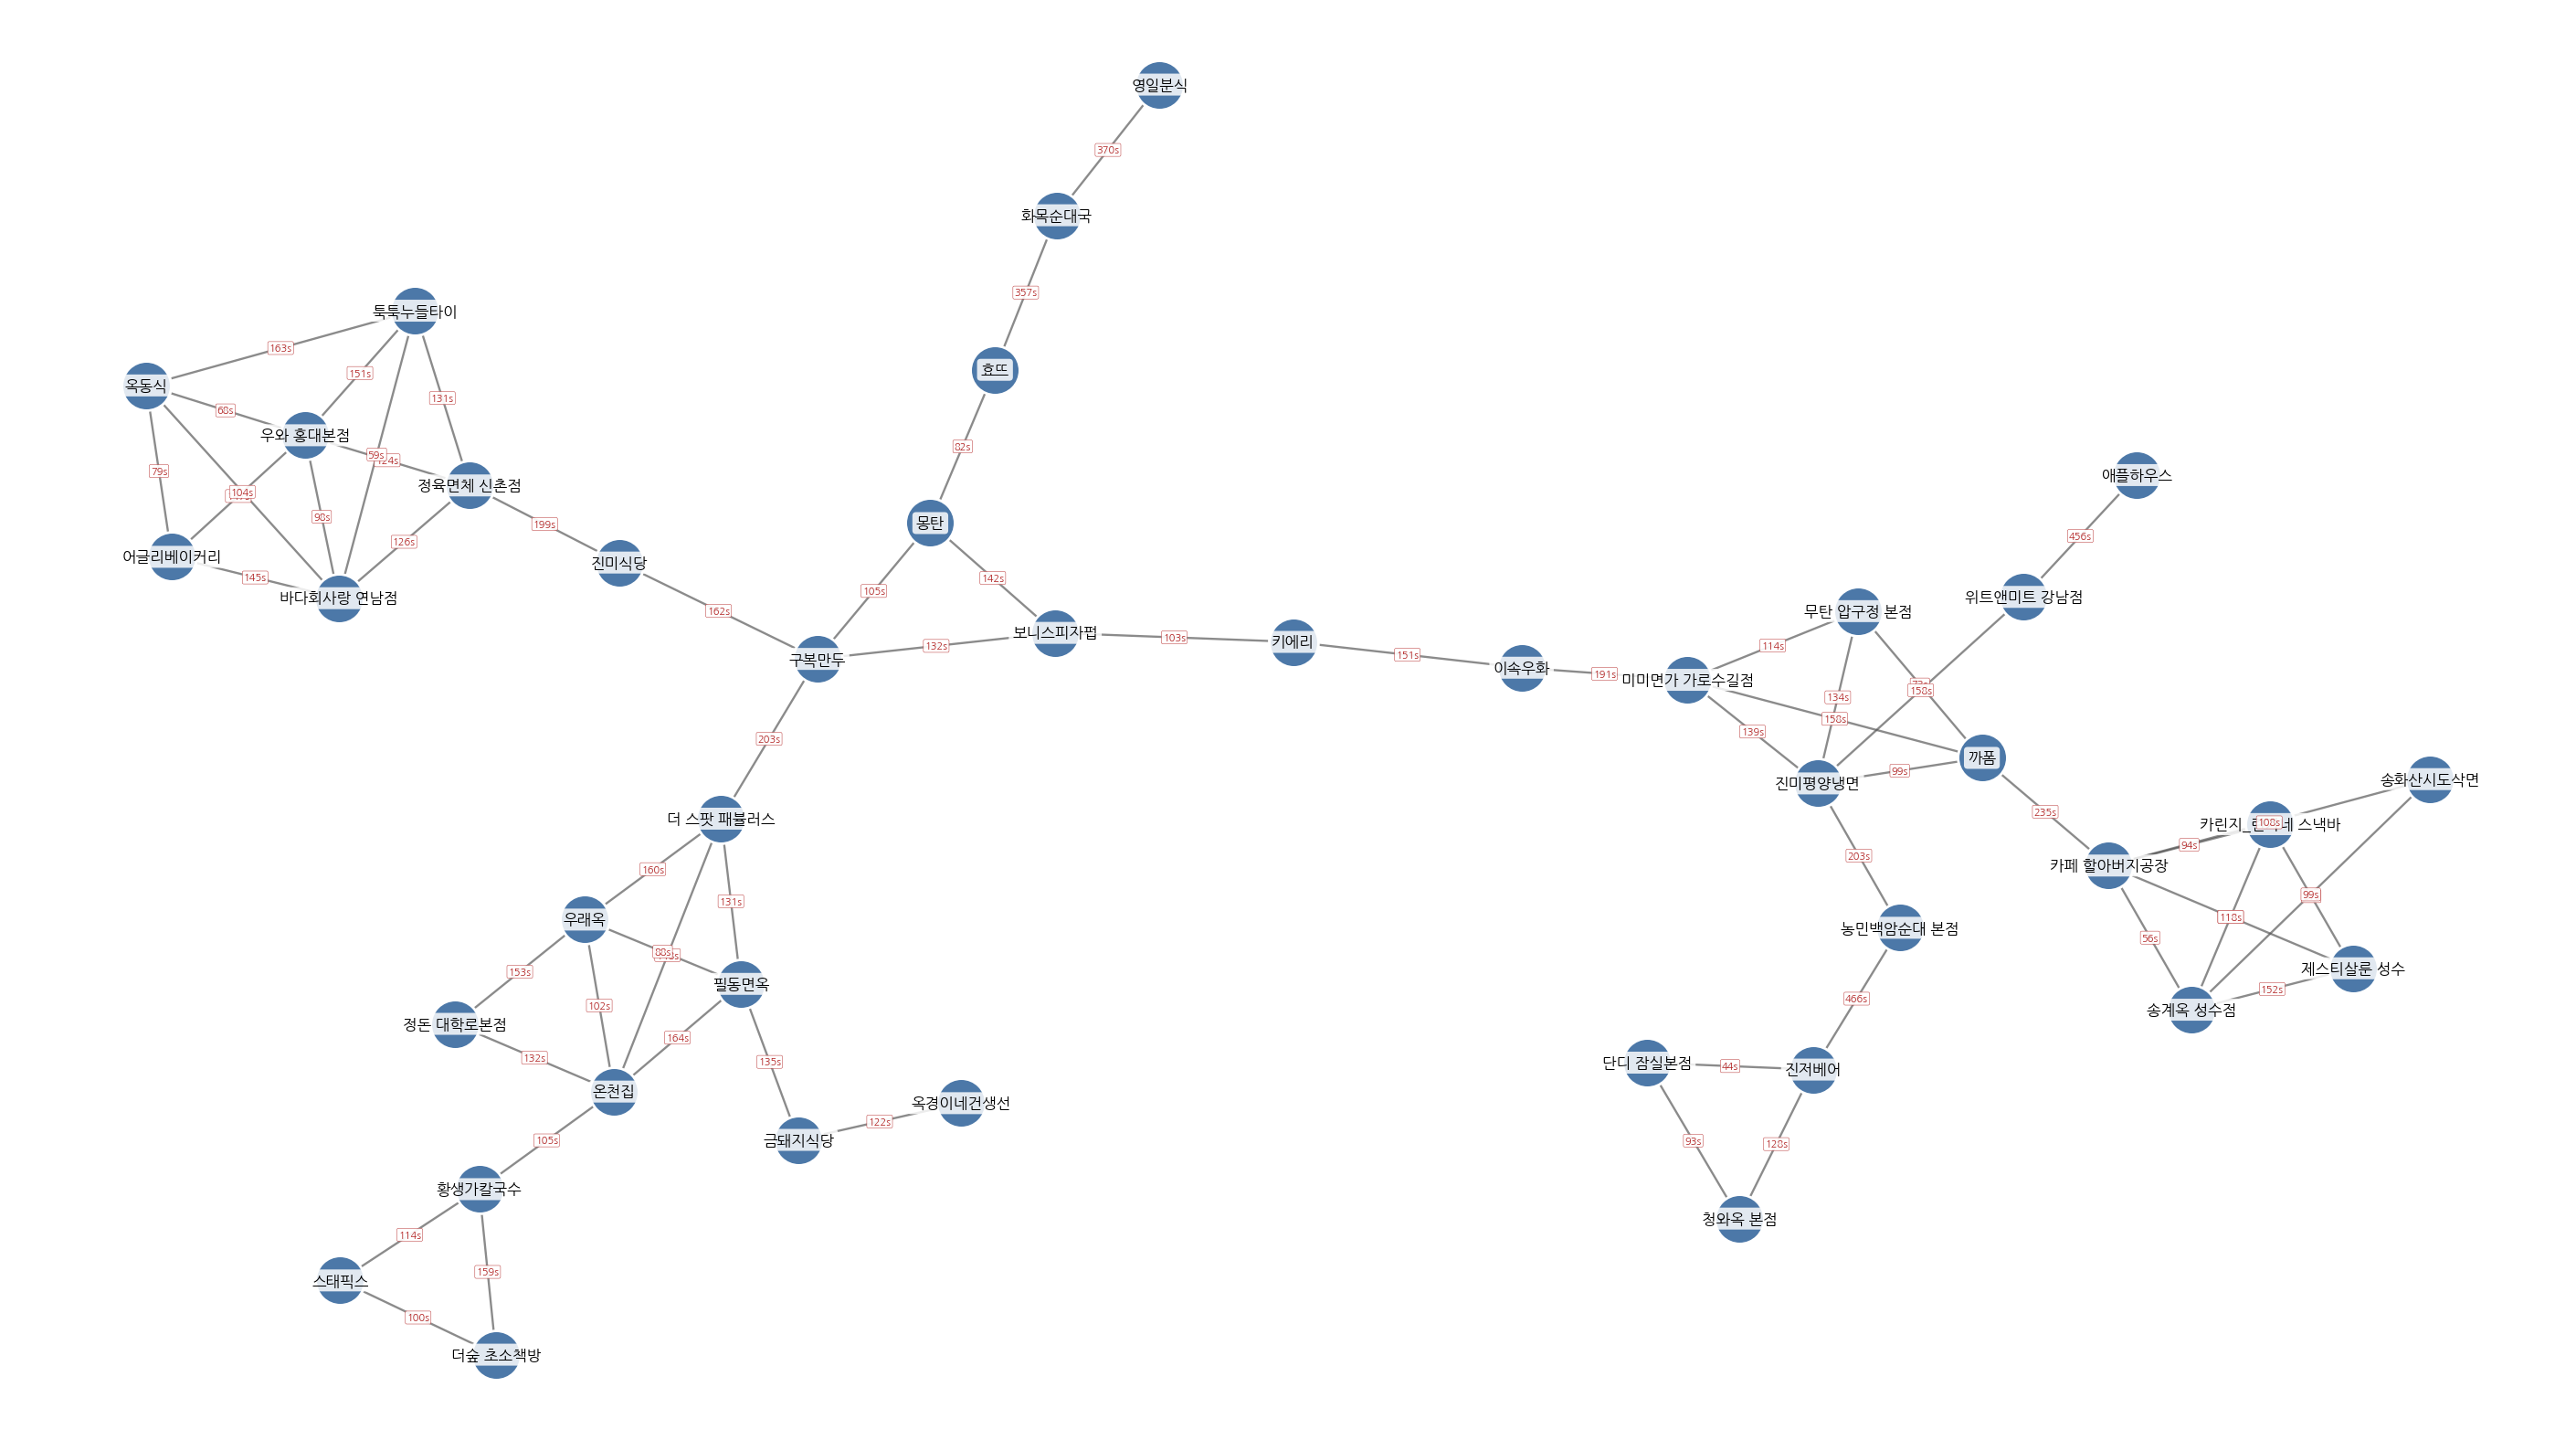

In [36]:
def get_graph_positions(graph):
    """Spread nodes with a force-directed layout to minimize node and label overlap."""
    pos = nx.spring_layout(
        graph,
        seed=42,
        k=2.8,
        iterations=1000,
        weight=None,
        scale=7.0,
    )
    pos = {node: [float(x), float(y)] for node, (x, y) in pos.items()}

    min_distance = 1.05
    step = 0.08

    for _ in range(700):
        max_push = 0.0
        nodes = list(pos)
        for i, a in enumerate(nodes):
            for b in nodes[i + 1:]:
                ax_, ay_ = pos[a]
                bx, by = pos[b]
                dx = ax_ - bx
                dy = ay_ - by
                distance = math.hypot(dx, dy)

                if distance < 1e-9:
                    dx, dy, distance = 0.001, 0.001, math.sqrt(2) * 0.001

                if distance < min_distance:
                    push = (min_distance - distance) * step / distance
                    push_x = dx * push
                    push_y = dy * push
                    pos[a][0] += push_x
                    pos[a][1] += push_y
                    pos[b][0] -= push_x
                    pos[b][1] -= push_y
                    max_push = max(max_push, abs(push_x) + abs(push_y))

        if max_push < 1e-5:
            break

    return {node: (x, y) for node, (x, y) in pos.items()}


def draw_restaurant_graph(graph, filename="graph.png"):
    pos = get_graph_positions(graph)

    fig, ax = plt.subplots(figsize=(28, 22))

    nx.draw_networkx_edges(
        graph,
        pos,
        width=1.7,
        edge_color="#555555",
        alpha=0.68,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=1500,
        node_color="#4C78A8",
        edgecolors="white",
        linewidths=2.0,
        ax=ax,
    )

    for node, (x, y) in pos.items():
        ax.text(
            x,
            y,
            node,
            fontsize=12,
            color="black",
            ha="center",
            va="center",
            fontproperties=KOREAN_FONT,
            bbox={"boxstyle": "round,pad=0.24", "facecolor": "white", "edgecolor": "none", "alpha": 0.84},
            zorder=5,
        )

    for u, v, data in graph.edges(data=True):
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            f"{data['weight']:.0f}s",
            fontsize=8,
            color="#B22222",
            ha="center",
            va="center",
            fontproperties=KOREAN_FONT,
            bbox={"boxstyle": "round,pad=0.14", "facecolor": "white", "edgecolor": "#B22222", "linewidth": 0.35, "alpha": 0.92},
            zorder=7,
        )

    xs = [x for x, _ in pos.values()]
    ys = [y for _, y in pos.values()]
    x_margin = (max(xs) - min(xs)) * 0.06
    y_margin = (max(ys) - min(ys)) * 0.06
    ax.set_xlim(min(xs) - x_margin, max(xs) + x_margin)
    ax.set_ylim(min(ys) - y_margin, max(ys) + y_margin)

    ax.set_axis_off()
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout(pad=0)
    plt.savefig(filename, dpi=220, bbox_inches="tight", pad_inches=0.01)
    plt.show()


draw_restaurant_graph(G)

## 2. DFS를 이용한 모든 음식점 방문 애니메이션

DFS(Depth-First Search) 순회 영상

[DFS 순회영상](./dfs.mp4)

In [41]:
def dfs_visit_steps(graph, start):
    """Return DFS visit steps as (current_node, visited_nodes, tree_edges)."""
    # 방문한 음식점, DFS 경로 간선, 애니메이션 프레임별 상태를 저장한다.
    visited = set()
    tree_edges = []
    steps = []

    def dfs(node):
        # 현재 음식점을 방문 처리하고, 이 순간의 DFS 상태를 한 프레임으로 기록한다.
        visited.add(node)
        steps.append((node, set(visited), list(tree_edges)))

        # 방문 순서가 매번 같도록 이웃 음식점 이름을 정렬한 뒤 DFS를 진행한다.
        for neighbor in sorted(graph.neighbors(node)):
            if neighbor not in visited:
                tree_edges.append((node, neighbor))
                dfs(neighbor)

    dfs(start)
    return steps


def save_dfs_animation(graph, start="금돼지식당", filename="dfs.mp4"):
    # 그래프 좌표와 DFS 방문 단계를 미리 계산한다.
    pos = get_graph_positions(graph)
    steps = dfs_visit_steps(graph, start)

    # MP4로 저장할 그림판과 ffmpeg writer를 준비한다.
    fig, ax = plt.subplots(figsize=(22, 16))
    writer = FFMpegWriter(fps=1.5, bitrate=4200)

    all_edges = list(graph.edges())

    def format_node_label(node):
        # 긴 음식점 이름은 공백 기준으로 줄바꿈해서 화면 밖으로 나가지 않게 한다.
        return node.replace(" ", "\n") if len(node) >= 8 else node

    def draw_frame(frame_index):
        # 이전 프레임을 지우고 현재 DFS 단계의 상태를 가져온다.
        ax.clear()
        current_node, visited_nodes, tree_edges = steps[frame_index]
        tree_edge_keys = {tuple(sorted(edge)) for edge in tree_edges}

        # DFS 경로에 포함된 간선은 강조하고, 나머지 간선은 배경 간선으로 그린다.
        base_edges = [edge for edge in all_edges if tuple(sorted(edge)) not in tree_edge_keys]
        highlight_edges = [edge for edge in all_edges if tuple(sorted(edge)) in tree_edge_keys]

        nx.draw_networkx_edges(
            graph,
            pos,
            edgelist=base_edges,
            width=3.4,
            edge_color="#666666",
            alpha=0.72,
            ax=ax,
        )
        nx.draw_networkx_edges(
            graph,
            pos,
            edgelist=highlight_edges,
            width=7.0,
            edge_color="#F58518",
            alpha=0.95,
            ax=ax,
        )

        # 현재 방문 중인 노드는 빨강, 이미 방문한 노드는 초록, 미방문 노드는 회색으로 표시한다.
        node_colors = []
        for node in graph.nodes():
            if node == current_node:
                node_colors.append("#E45756")
            elif node in visited_nodes:
                node_colors.append("#54A24B")
            else:
                node_colors.append("#BFC7D5")

        nx.draw_networkx_nodes(
            graph,
            pos,
            node_size=950,
            node_color=node_colors,
            edgecolors="white",
            linewidths=1.1,
            ax=ax,
        )

        # 각 노드 위치에 음식점 이름을 크게 표시한다.
        for node, (x, y) in pos.items():
            ax.text(
                x,
                y,
                format_node_label(node),
                fontsize=19,
                color="black",
                ha="center",
                va="center",
                fontproperties=KOREAN_FONT,
                bbox={"boxstyle": "round,pad=0.18", "facecolor": "white", "edgecolor": "none", "alpha": 0.76},
                linespacing=0.9,
                zorder=5,
            )

        # 간선의 중앙에 이동 시간(weight)을 초 단위로 표시한다.
        for u, v, data in graph.edges(data=True):
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            ax.text(
                (x1 + x2) / 2,
                (y1 + y2) / 2,
                f"{data['weight']:.0f}s",
                fontsize=12,
                color="#B22222",
                ha="center",
                va="center",
                fontproperties=KOREAN_FONT,
                bbox={"boxstyle": "round,pad=0.10", "facecolor": "white", "edgecolor": "#B22222", "linewidth": 0.35, "alpha": 0.82},
                zorder=7,
            )

        # 그래프가 잘리지 않도록 전체 노드 범위에 여백을 추가한다.
        xs = [x for x, _ in pos.values()]
        ys = [y for _, y in pos.values()]
        x_margin = (max(xs) - min(xs)) * .04
        y_margin = (max(ys) - min(ys)) * 0
        ax.set_xlim(min(xs) - x_margin, max(xs) + x_margin)
        ax.set_ylim(min(ys) - y_margin, max(ys) + y_margin)
        ax.set_axis_off()
        ax.set_aspect("equal", adjustable="box")

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # DFS 단계마다 한 장씩 그려서 MP4 프레임으로 저장한다.
    with writer.saving(fig, filename, dpi=130):
        for frame_index in range(len(steps)):
            draw_frame(frame_index)
            writer.grab_frame()

    plt.close(fig)
    print(f"DFS visited {len(steps)} restaurants. Saved: {filename}")


save_dfs_animation(G)


/tmp/ipykernel_6560/278747433.py:57: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


DFS visited 40 restaurants. Saved: dfs.mp4


## 3. BFS를 이용한 모든 음식점 방문 애니메이션

BFS(Breadth-First Search)를 직접 구현하고, 큐에 들어온 순서대로 음식점을 방문하는 과정을 `bfs.mp4`로 저장한다.


In [ ]:
from collections import deque


def bfs_visit_steps(graph, start):
    """Return BFS visit steps as (current_node, visited_nodes, tree_edges)."""
    # 큐에 넣은 음식점(seen)과 실제 방문 완료한 음식점(visited)을 분리한다.
    seen = {start}
    visited = set()
    tree_edges = []
    steps = []
    queue = deque([(start, None)])

    while queue:
        # 큐에서 하나를 꺼낼 때만 방문 처리해서 프레임마다 음식점 한 개씩 방문하게 한다.
        node, parent = queue.popleft()
        visited.add(node)
        if parent is not None:
            tree_edges.append((parent, node))
        steps.append((node, set(visited), list(tree_edges)))

        # 방문 순서가 매번 같도록 이웃 음식점 이름을 정렬한 뒤 BFS를 진행한다.
        for neighbor in sorted(graph.neighbors(node)):
            if neighbor not in seen:
                seen.add(neighbor)
                queue.append((neighbor, node))

    return steps


def save_bfs_animation(graph, start="금돼지식당", filename="bfs.mp4"):
    # 그래프 좌표와 BFS 방문 단계를 미리 계산한다.
    pos = get_graph_positions(graph)
    steps = bfs_visit_steps(graph, start)

    # MP4로 저장할 그림판과 ffmpeg writer를 준비한다.
    fig, ax = plt.subplots(figsize=(22, 16))
    writer = FFMpegWriter(fps=1.5, bitrate=4200)

    all_edges = list(graph.edges())

    def format_node_label(node):
        # 긴 음식점 이름은 공백 기준으로 줄바꿈해서 화면 밖으로 나가지 않게 한다.
        return node.replace(" ", "\n") if len(node) >= 8 else node

    def draw_frame(frame_index):
        # 이전 프레임을 지우고 현재 BFS 단계의 상태를 가져온다.
        ax.clear()
        current_node, visited_nodes, tree_edges = steps[frame_index]
        tree_edge_keys = {tuple(sorted(edge)) for edge in tree_edges}

        # BFS 경로에 포함된 간선은 강조하고, 나머지 간선은 배경 간선으로 그린다.
        base_edges = [edge for edge in all_edges if tuple(sorted(edge)) not in tree_edge_keys]
        highlight_edges = [edge for edge in all_edges if tuple(sorted(edge)) in tree_edge_keys]

        nx.draw_networkx_edges(
            graph,
            pos,
            edgelist=base_edges,
            width=3.4,
            edge_color="#666666",
            alpha=0.72,
            ax=ax,
        )
        nx.draw_networkx_edges(
            graph,
            pos,
            edgelist=highlight_edges,
            width=7.0,
            edge_color="#4C78A8",
            alpha=0.95,
            ax=ax,
        )

        # 현재 방문 중인 노드는 빨강, 이미 방문한 노드는 초록, 미방문 노드는 회색으로 표시한다.
        node_colors = []
        for node in graph.nodes():
            if node == current_node:
                node_colors.append("#E45756")
            elif node in visited_nodes:
                node_colors.append("#54A24B")
            else:
                node_colors.append("#BFC7D5")

        nx.draw_networkx_nodes(
            graph,
            pos,
            node_size=950,
            node_color=node_colors,
            edgecolors="white",
            linewidths=1.1,
            ax=ax,
        )

        # 각 노드 위치에 음식점 이름을 크게 표시한다.
        for node, (x, y) in pos.items():
            ax.text(
                x,
                y,
                format_node_label(node),
                fontsize=19,
                color="black",
                ha="center",
                va="center",
                fontproperties=KOREAN_FONT,
                bbox={"boxstyle": "round,pad=0.18", "facecolor": "white", "edgecolor": "none", "alpha": 0.76},
                linespacing=0.9,
                zorder=5,
            )

        # 간선의 중앙에 이동 시간(weight)을 초 단위로 표시한다.
        for u, v, data in graph.edges(data=True):
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            ax.text(
                (x1 + x2) / 2,
                (y1 + y2) / 2,
                f"{data['weight']:.0f}s",
                fontsize=12,
                color="#B22222",
                ha="center",
                va="center",
                fontproperties=KOREAN_FONT,
                bbox={"boxstyle": "round,pad=0.10", "facecolor": "white", "edgecolor": "#B22222", "linewidth": 0.35, "alpha": 0.82},
                zorder=7,
            )

        # 그래프가 잘리지 않도록 전체 노드 범위에 여백을 추가한다.
        xs = [x for x, _ in pos.values()]
        ys = [y for _, y in pos.values()]
        x_margin = (max(xs) - min(xs)) * .04
        y_margin = (max(ys) - min(ys)) * 0
        ax.set_xlim(min(xs) - x_margin, max(xs) + x_margin)
        ax.set_ylim(min(ys) - y_margin, max(ys) + y_margin)
        ax.set_axis_off()
        ax.set_aspect("equal", adjustable="box")

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # BFS 단계마다 한 장씩 그려서 MP4 프레임으로 저장한다.
    with writer.saving(fig, filename, dpi=130):
        for frame_index in range(len(steps)):
            draw_frame(frame_index)
            writer.grab_frame()

    plt.close(fig)
    print(f"BFS visited {len(steps)} restaurants. Saved: {filename}")


save_bfs_animation(G)
